In [1]:
import xarray as xr
import os
import dask
import h5netcdf
import scipy
import pandas as pd
import re
import numpy as np
from datetime import timedelta
import datetime
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.colors import TwoSlopeNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker  
import pint
from pint import UnitRegistry
ureg = UnitRegistry()
import matplotlib.pylab as pylab
params = {'legend.fontsize': 'large',
         'axes.labelsize': 22,
         'axes.titlesize':'large',
         'xtick.labelsize':18,
         'ytick.labelsize':18,
         'figure.figsize':[10,7],
         'figure.titlesize':22}
pylab.rcParams.update(params)

import sys
sys.path.append(".")  # Ensures the current directory is in the Python path
sys.path.append("/home/paaa/python_scripts/")
import my_functions as mfun
from my_classes import DatasetProcessor


In [2]:
dir_in   = "/perm/paaa/IFS/netherlands"
dir_obs         = "/perm/paaa/observations"


exp_names = [
    ('ctrl'     , 'itvc_ctrl_flxntend'       ,  'Control'),
    ('ctrl_9km' , 'ivln_9km_flxntend'   ,  'Control 9 km')
]
nemo_exp_names = [
    ('SPP_all',     'j0a2_SPP_noIC_noBFAS', 'SPP all'   , 'grey'),

]


In [3]:
col = ['#D04848','#6895D2','#F3B95F','#59981A','#58171A','#2F4F4F']
sty = ['-','--',':', '-.']

In [4]:
levels = ['z','srf']
lead_time = 0 # do you want to analayse FC day1 (leasd_time = 0) or FC day2 (leasd_time = 24) ? 

str_time = '2022-05-15T03:00'
end_time = '2022-05-21T02:00'

UTC_to_LT = +2 #hours from UTC

#######################################
# Time limits
t0 = datetime.datetime.strptime(str_time, "%Y-%m-%dT%H:%M")
t1 = datetime.datetime.strptime(end_time, "%Y-%m-%dT%H:%M")

cabauw ={
        "lat": 51.971,
        "lon": 4.927,
        "z": [5, 60, 100, 180]
    }

loobos ={
        "lat": 52.166,
        "lon": 5.744,
        "z": [24]
    }

In [5]:
spp_file = f"/perm/paaa/IFS/cabauw/eps_nemo/j0a2_SPP_noIC_noBFAS_all_pl_20220515_24cabauw.nc"
SPP_all = xr.open_mfdataset(spp_file, combine="by_coords")

In [22]:
SPP_all['co2'] = mfun.concentration_to_ppm('co2',SPP_all['co2'])

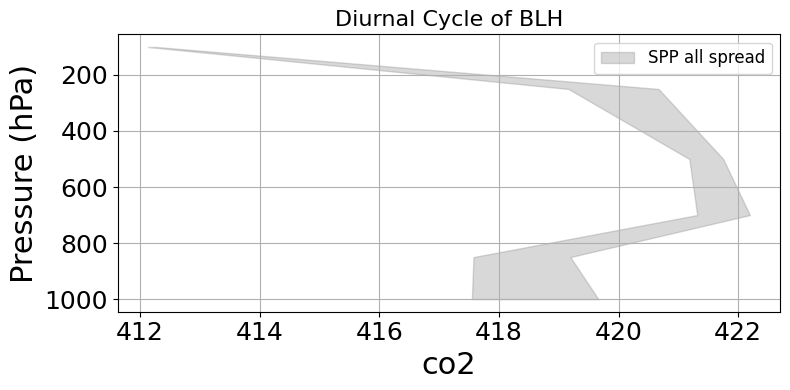

In [23]:
var = 'co2'
plt.figure(figsize=(8, 4))
# Plot shaded ensemble spreads (averaged over time and space)
for i, (ens_key, _, ens_lab, ens_color) in enumerate(nemo_exp_names):
    min_member = SPP_all[var].min(dim='number')
    max_member = SPP_all[var].max(dim='number')

    mean_min_member = min_member.mean(dim=['time','latitude','longitude'])
    mean_max_member = max_member.mean(dim=['time','latitude','longitude'])

    plt.fill_betweenx(
        mean_min_member['level'].values,
        mean_min_member.values,
        mean_max_member.values,
        color=ens_color,
        alpha=max(0.05, 0.3 - 0.1 * i),
        label=f'{ens_lab} spread',
    )
plt.xlabel(var)
plt.ylabel('Pressure (hPa)')
# plt.title('Diurnal Cycle of BLH', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
# invert y-axis so level decreases upward (yincrease = False)
plt.gca().invert_yaxis()